# V3 clean broad weak dataset: LLM multilabel evaluation

This notebook re-evaluates the cached LLM classifiers on the new v3 broad/weak multilabel dataset.

Main metric: `micro_f1` over the 36 binary factor labels.

Supporting metrics:
- `macro_f1_supported`: macro-F1 only over factors with positive gold support.
- `sample_f1_empty_correct`: average per-news multilabel F1, with empty-empty counted as 1.
- `any_relevant_f1`: relevance gate quality: does the news have at least one relevant factor.
- per-factor precision/recall/F1.

Important scope note: the new CSV contains 1000 rows, but the old cached full LLM predictions cover
only 739 of those rows. The richer search experiments cover 237 rows. All comparisons below use
explicit overlap sets so we do not silently count missing predictions as model failures.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
OUT = ROOT / "analysis_outputs"
DATASET_PATH = OUT / "v3_clean_broad_weak_dataset_1000.csv"

from analyzer.factors import FACTOR_CONFIG

FACTOR_KEYS = [item["key"] for item in FACTOR_CONFIG]
FACTOR_NAMES = {item["key"]: item["name"] for item in FACTOR_CONFIG}

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)

## Dataset and label sanity checks

In [2]:
df = pd.read_csv(DATASET_PATH, encoding="utf-8-sig")
df["dataset_row_id"] = df["dataset_row_id"].astype(int)
df = df.set_index("dataset_row_id", drop=False)

missing_factor_cols = [key for key in FACTOR_KEYS if f"factor__{key}" not in df.columns]
duplicate_ids = int(df.index.duplicated().sum())

Y_all = pd.DataFrame(
    {
        key: pd.to_numeric(df[f"factor__{key}"], errors="coerce").fillna(0).astype(int).clip(0, 1)
        for key in FACTOR_KEYS
    },
    index=df.index,
)

strength_rows = []
for key in FACTOR_KEYS:
    support_mask = Y_all[key].eq(1)
    vc = df.loc[support_mask, f"strength__{key}"].fillna("NA").astype(str).str.lower().value_counts()
    strength_rows.append(
        {
            "factor_key": key,
            "support": int(support_mask.sum()),
            "direct": int(vc.get("direct", 0)),
            "context": int(vc.get("context", 0)),
            "weak": int(vc.get("weak", 0)),
        }
    )
support = pd.DataFrame(strength_rows).sort_values("support", ascending=False)

overview = pd.DataFrame(
    [
        {"metric": "rows", "value": len(df)},
        {"metric": "unique_dataset_row_id", "value": df.index.nunique()},
        {"metric": "duplicate_dataset_row_id", "value": duplicate_ids},
        {"metric": "factor_columns_missing", "value": len(missing_factor_cols)},
        {"metric": "factor_count", "value": len(FACTOR_KEYS)},
        {"metric": "positive_factor_pairs", "value": int(Y_all.values.sum())},
        {"metric": "mean_labels_per_news", "value": round(float(Y_all.sum(axis=1).mean()), 3)},
        {"metric": "empty_news", "value": int((Y_all.sum(axis=1) == 0).sum())},
        {"metric": "direct_labels", "value": int(support["direct"].sum())},
        {"metric": "context_labels", "value": int(support["context"].sum())},
        {"metric": "weak_labels", "value": int(support["weak"].sum())},
        {"metric": "zero_support_factors", "value": int((support["support"] == 0).sum())},
    ]
)
overview

,metric,value
0,rows,1000.000
1,unique_dataset_row_id,1000.000
2,duplicate_dataset_row_id,0.000
3,factor_columns_missing,0.000
4,factor_count,36.000
5,positive_factor_pairs,2765.000
6,mean_labels_per_news,2.765
7,empty_news,33.000
8,direct_labels,1158.000
9,context_labels,1012.000


In [3]:
display(support.head(20))
display(support.tail(12))

,factor_key,support,direct,context,weak
29,industrial_production_index,526,244,162,120
30,enterprises_count,448,301,92,55
26,consumer_price_index,364,224,52,88
31,crime_count,313,212,26,75
8,life_expectancy,185,23,156,6
11,per_capita_income,181,20,73,88
12,real_income_index,173,0,168,5
25,housing_area_per_capita,82,35,46,1
34,mortality_rate,75,45,30,0
16,hospitals,63,10,51,2


,factor_key,support,direct,context,weak
7,infant_mortality,6,0,1,5
10,female_population,5,0,0,5
20,preschool_coverage,4,0,0,4
28,secondary_housing_price_index,4,0,1,3
15,child_living_wage,3,0,3,0
22,maternity_capital,2,2,0,0
2,marriage_rate,2,0,0,2
1,divorce_rate,1,0,0,1
17,outpatient_clinics,1,0,1,0
23,childcare_allowance,0,0,0,0


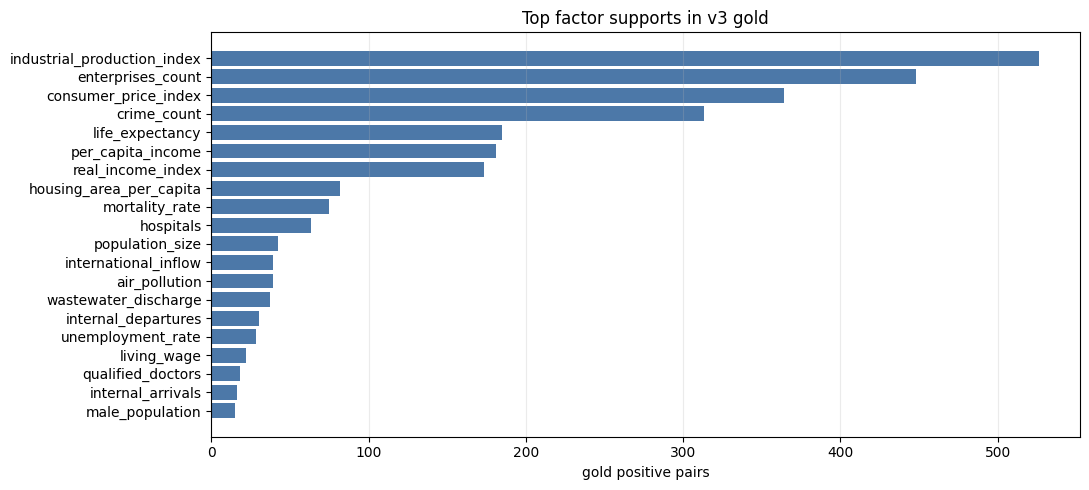

In [4]:
fig, ax = plt.subplots(figsize=(11, 5))
top = support.head(20).iloc[::-1]
ax.barh(top["factor_key"], top["support"], color="#4c78a8")
ax.set_title("Top factor supports in v3 gold")
ax.set_xlabel("gold positive pairs")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## Prediction coverage

In [5]:
source_paths = {
    "full_production_v1": OUT / "prompt_search_full_production_v1_gemma4-e2b_5df03950348d_b6a2d2f27b85.csv",
    "full_balanced_recall_v2": OUT / "prompt_search_full_balanced_recall_v2_gemma4-e2b_5df03950348d_e98b1a3c5abc.csv",
    "search_production_v1": OUT / "prompt_search_search_production_v1_gemma4-e2b_5df03950348d_b6a2d2f27b85.csv",
    "search_balanced_recall_v2": OUT / "prompt_search_search_balanced_recall_v2_gemma4-e2b_5df03950348d_e98b1a3c5abc.csv",
    "search_primary_first_v2": OUT / "prompt_search_search_primary_first_v2_gemma4-e2b_5df03950348d_5f153b0981f2.csv",
    "search_hard_negative_v2": OUT / "prompt_search_search_hard_negative_v2_gemma4-e2b_5df03950348d_1a35bcd28344.csv",
    "search_few_shot_major_v3": OUT / "prompt_search_search_few_shot_major_v3_gemma4-e2b_5df03950348d_0c3d39008fbb.csv",
    "recall_max_think_false": OUT / "thinking_recall_experiment_recall_max_v1_think_false.csv",
    "recall_max_think_true": OUT / "thinking_recall_experiment_recall_max_v1_think_true.csv",
    "grouped_event_think_true": OUT / "grouped_event_v1_search_think_true.csv",
    "latent_candidate_v2_bad_schema": OUT / "thinking_recall_experiment_latent_candidate_v2_think_true.csv",
    "latent_candidate_v3_think_true": OUT / "thinking_recall_experiment_latent_candidate_v3_think_true.csv",
}

coverage_rows = []
for name, path in source_paths.items():
    if not path.exists():
        coverage_rows.append({"source": name, "exists": False, "prediction_ids": 0, "overlap_v3": 0})
        continue
    ids = pd.read_csv(path, usecols=["dataset_row_id"])["dataset_row_id"].astype(int).unique()
    coverage_rows.append(
        {
            "source": name,
            "exists": True,
            "prediction_ids": len(ids),
            "overlap_v3": len(set(ids).intersection(df.index.astype(int))),
            "min_id": int(np.min(ids)),
            "max_id": int(np.max(ids)),
        }
    )
coverage = pd.DataFrame(coverage_rows)
coverage

,source,exists,prediction_ids,overlap_v3,min_id,max_id
0,full_production_v1,True,1000,739,1,1000
1,full_balanced_recall_v2,True,1000,739,1,1000
2,search_production_v1,True,300,237,1,990
3,search_balanced_recall_v2,True,300,237,1,990
4,search_primary_first_v2,True,300,237,1,990
5,search_hard_negative_v2,True,300,237,1,990
6,search_few_shot_major_v3,True,300,237,1,990
7,recall_max_think_false,True,300,237,1,990
8,recall_max_think_true,True,300,237,1,990
9,grouped_event_think_true,True,300,237,1,990


## Main scoreboard

`full_overlap` rows are evaluated on the 739 v3 rows that already have full cached predictions.
`search_overlap` rows are evaluated on the common 237-row overlap for prompt-search, thinking,
grouped, and latent-candidate experiments.

In [6]:
single_source = pd.read_csv(OUT / "v3_clean_broad_weak_single_source_threshold_metrics.csv")
single_source["overlap_group"] = np.where(single_source["source"].str.startswith("full_"), "full_overlap", "search_overlap")

best_single = (
    single_source.sort_values("micro_f1", ascending=False)
    .groupby("overlap_group", as_index=False)
    .head(8)
    [[
        "overlap_group",
        "config",
        "n_news",
        "gold_positive_pairs",
        "pred_positive_pairs",
        "micro_precision",
        "micro_recall",
        "micro_f1",
        "macro_f1_supported",
        "sample_f1_empty_correct",
        "any_relevant_f1",
        "false_relevant_news",
        "missed_all_relevant_news",
    ]]
)
best_single.round(4)

,overlap_group,config,n_news,gold_positive_pairs,pred_positive_pairs,micro_precision,micro_recall,micro_f1,macro_f1_supported,sample_f1_empty_correct,any_relevant_f1,false_relevant_news,missed_all_relevant_news
180,search_overlap,latent_candidate_v3_think_true@0.20,237,656,429,0.5385,0.3521,0.4258,0.2695,0.3787,0.9784,10,0
178,search_overlap,latent_candidate_v3_think_true@0.10,237,656,429,0.5385,0.3521,0.4258,0.2695,0.3787,0.9784,10,0
181,search_overlap,latent_candidate_v3_think_true@0.25,237,656,429,0.5385,0.3521,0.4258,0.2695,0.3787,0.9784,10,0
182,search_overlap,latent_candidate_v3_think_true@0.30,237,656,429,0.5385,0.3521,0.4258,0.2695,0.3787,0.9784,10,0
179,search_overlap,latent_candidate_v3_think_true@0.15,237,656,429,0.5385,0.3521,0.4258,0.2695,0.3787,0.9784,10,0
177,search_overlap,latent_candidate_v3_think_true@0.05,237,656,429,0.5385,0.3521,0.4258,0.2695,0.3787,0.9784,10,0
185,search_overlap,latent_candidate_v3_think_true@0.45,237,656,327,0.6147,0.3064,0.4090,0.2555,0.3658,0.9417,9,17
186,search_overlap,latent_candidate_v3_think_true@0.50,237,656,327,0.6147,0.3064,0.4090,0.2555,0.3658,0.9417,9,17
22,full_overlap,full_balanced_recall_v2@0.30,739,2010,588,0.7449,0.2179,0.3372,0.1608,0.3416,0.8735,11,150
21,full_overlap,full_balanced_recall_v2@0.25,739,2010,588,0.7449,0.2179,0.3372,0.1608,0.3416,0.8735,11,150


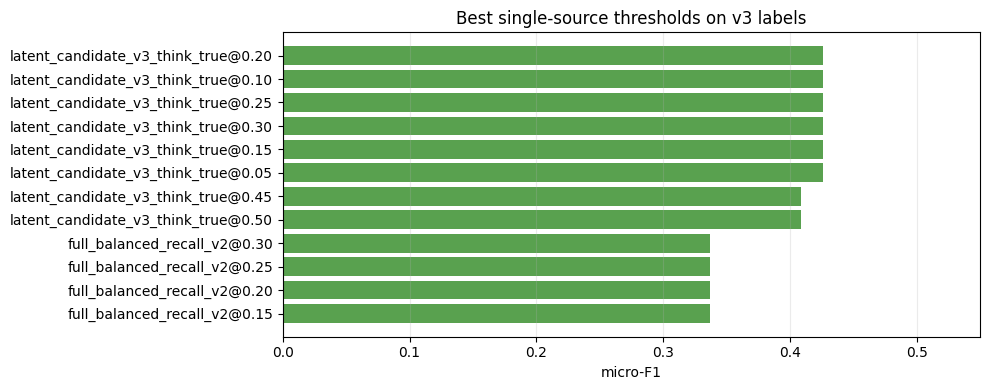

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
plot_df = best_single.head(12).iloc[::-1]
ax.barh(plot_df["config"], plot_df["micro_f1"], color="#59a14f")
ax.set_title("Best single-source thresholds on v3 labels")
ax.set_xlabel("micro-F1")
ax.set_xlim(0, max(0.55, float(plot_df["micro_f1"].max()) + 0.05))
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## Ensemble and label-scope checks

In [8]:
ens = pd.read_csv(OUT / "v3_clean_broad_weak_ensemble_metrics.csv")

best_ens_all = ens[ens["label_scope"].eq("all")].sort_values("micro_f1", ascending=False).head(15)
best_ens_direct_context = ens[ens["label_scope"].eq("direct_context")].sort_values("micro_f1", ascending=False).head(8)
best_ens_direct = ens[ens["label_scope"].eq("direct")].sort_values("micro_f1", ascending=False).head(8)

display(
    best_ens_all[
        [
            "config",
            "n_news",
            "gold_positive_pairs",
            "pred_positive_pairs",
            "micro_precision",
            "micro_recall",
            "micro_f1",
            "macro_f1_supported",
            "sample_f1_empty_correct",
            "any_relevant_f1",
            "missed_all_relevant_news",
        ]
    ].round(4)
)
display(best_ens_direct_context[["config", "gold_positive_pairs", "micro_precision", "micro_recall", "micro_f1", "any_relevant_f1"]].round(4))
display(best_ens_direct[["config", "gold_positive_pairs", "micro_precision", "micro_recall", "micro_f1", "any_relevant_f1"]].round(4))

,config,n_news,gold_positive_pairs,pred_positive_pairs,micro_precision,micro_recall,micro_f1,macro_f1_supported,sample_f1_empty_correct,any_relevant_f1,missed_all_relevant_news
92,balanced030_or_thinking030_or_grouped035_or_latent045,237,656,468,0.5705,0.4070,0.4751,0.3066,0.4439,0.9739,3
6,all_search_sources_max@0.35,237,656,464,0.5733,0.4055,0.4750,0.3706,0.4295,0.9626,8
7,all_search_sources_max@0.40,237,656,464,0.5733,0.4055,0.4750,0.3706,0.4295,0.9626,8
10,all_search_sources_max@0.55,237,656,460,0.5761,0.4040,0.4749,0.3614,0.4291,0.9626,8
11,all_search_sources_max@0.60,237,656,460,0.5761,0.4040,0.4749,0.3614,0.4291,0.9626,8
8,all_search_sources_max@0.45,237,656,460,0.5761,0.4040,0.4749,0.3614,0.4291,0.9626,8
9,all_search_sources_max@0.50,237,656,460,0.5761,0.4040,0.4749,0.3614,0.4291,0.9626,8
48,balanced_plus_latent_v3_max@0.20,237,656,480,0.5542,0.4055,0.4683,0.2797,0.4318,0.9784,0
49,balanced_plus_latent_v3_max@0.25,237,656,480,0.5542,0.4055,0.4683,0.2797,0.4318,0.9784,0
50,balanced_plus_latent_v3_max@0.30,237,656,480,0.5542,0.4055,0.4683,0.2797,0.4318,0.9784,0


,config,gold_positive_pairs,micro_precision,micro_recall,micro_f1,any_relevant_f1
186,balanced030_or_thinking030_or_grouped035_or_latent045,502,0.4893,0.4562,0.4722,0.9142
102,all_search_sources_max@0.45,502,0.4913,0.4502,0.4699,0.9108
103,all_search_sources_max@0.50,502,0.4913,0.4502,0.4699,0.9108
104,all_search_sources_max@0.55,502,0.4913,0.4502,0.4699,0.9108
105,all_search_sources_max@0.60,502,0.4913,0.4502,0.4699,0.9108
184,balanced030_or_latent045,502,0.5419,0.4124,0.4683,0.9133
100,all_search_sources_max@0.35,502,0.4871,0.4502,0.4679,0.9108
101,all_search_sources_max@0.40,502,0.4871,0.4502,0.4679,0.9108


,config,gold_positive_pairs,micro_precision,micro_recall,micro_f1,any_relevant_f1
278,balanced030_or_latent045,243,0.3586,0.5638,0.4384,0.7766
213,classic_prompt_search_max@0.55,243,0.4518,0.4239,0.4374,0.7678
214,classic_prompt_search_max@0.60,243,0.4518,0.4239,0.4374,0.7678
212,classic_prompt_search_max@0.50,243,0.4518,0.4239,0.4374,0.7678
211,classic_prompt_search_max@0.45,243,0.4518,0.4239,0.4374,0.7678
210,classic_prompt_search_max@0.40,243,0.4518,0.4239,0.4374,0.7678
209,classic_prompt_search_max@0.35,243,0.4518,0.4239,0.4374,0.7678
256,balanced_thinking_grouped_latent_v3_max@0.45,243,0.3397,0.5885,0.4307,0.7742


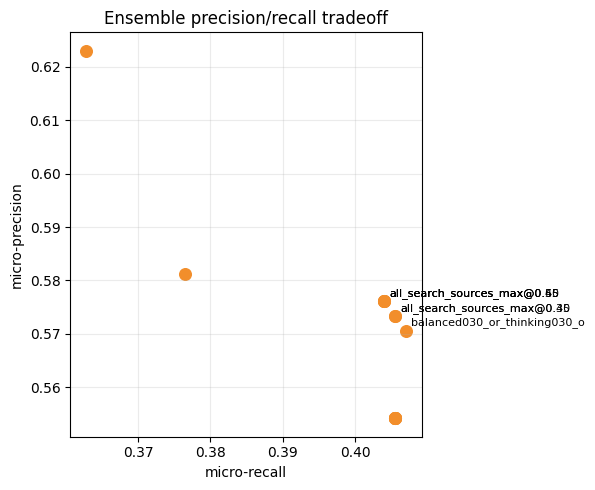

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(best_ens_all["micro_recall"], best_ens_all["micro_precision"], s=70, color="#f28e2b")
for _, row in best_ens_all.head(6).iterrows():
    ax.annotate(str(row["config"])[:28], (row["micro_recall"], row["micro_precision"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.set_title("Ensemble precision/recall tradeoff")
ax.set_xlabel("micro-recall")
ax.set_ylabel("micro-precision")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Sentiment on true-positive factor pairs

Sentiment is evaluated only where both gold and model agree that a factor is relevant.
This isolates sentiment quality from factor-detection misses and false positives.

Expansion-added labels are not included here because they do not have an independent LLM sentiment score.

In [10]:
sentiment = pd.read_csv(OUT / "v3_clean_broad_weak_sentiment_metrics.csv")
sentiment.round(4)

,config,tp_factor_pairs,sentiment_accuracy_on_tp,sentiment_macro_f1_on_tp,negative_share_gold_on_tp,neutral_share_gold_on_tp,positive_share_gold_on_tp
0,full_balanced_recall_v2@0.30,438,0.5114,0.5066,0.3858,0.3311,0.2831
1,search_balanced_recall_v2@0.30,137,0.5766,0.5592,0.4453,0.3139,0.2409
2,latent_candidate_v3_think_true@0.30,231,0.6104,0.5604,0.4545,0.2857,0.2597
3,latent_candidate_v3_think_true@0.45,201,0.6468,0.6012,0.4527,0.3035,0.2438
4,recall_max_think_true@0.30,146,0.6027,0.5568,0.4795,0.3014,0.2192
5,grouped_event_think_true@0.35,92,0.6304,0.5496,0.5870,0.2283,0.1848
6,best_prompt_union_mixed@source_max_score,267,0.6105,0.5565,0.4644,0.2959,0.2397


## V3-aware expansion experiment

The broad v3 taxonomy often marks contextual co-labels. Example: one economic or industrial item
can carry `consumer_price_index`, `real_income_index`, `per_capita_income`, `industrial_production_index`,
and `enterprises_count` at once.

A plain threshold cannot recover labels that no prompt emitted. This experiment learns simple
candidate-expansion rules on half of the 237-row search overlap and reports the result on the other half.
The goal is not to claim final production quality, but to test whether the error shape is fixable by
v3-aware co-label expansion.

In [11]:
expansion = pd.read_csv(OUT / "v3_clean_broad_weak_expansion_holdout_metrics.csv")
prefix = pd.read_csv(OUT / "v3_clean_broad_weak_expansion_prefix_metrics.csv")
rules = pd.read_csv(OUT / "v3_clean_broad_weak_greedy_expansion_rules.csv")

display(expansion.round(4))
display(rules.head(10).round(4))

,split,config,n_news,gold_pairs,pred_pairs,tp,fp,fn,precision,recall,micro_f1,any_f1
0,tune,base_mixed,118,331,226,130,96,201,0.5752,0.3927,0.4668,0.9694
1,tune,greedy_expanded,118,331,435,264,171,67,0.6069,0.7976,0.6893,0.9694
2,holdout,base_mixed,119,325,242,137,105,188,0.5661,0.4215,0.4832,0.9784
3,holdout,greedy_expanded,119,325,447,209,238,116,0.4676,0.6431,0.5415,0.9784
4,all,base_mixed,237,656,468,267,201,389,0.5705,0.4070,0.4751,0.9739
5,all,greedy_expanded,237,656,882,473,409,183,0.5363,0.7210,0.6151,0.9739


,step,trigger,target,tune_micro_f1,tune_micro_precision,tune_micro_recall,tune_added_precision,tune_added_tp,tune_added_count,all_added_count
0,1,latent_v3@0.05:consumer_price_index,real_income_index,0.5093,0.5814,0.4532,0.6250,20,32,59
1,2,latent_v3@0.05:consumer_price_index,enterprises_count,0.5469,0.5889,0.5106,0.6552,19,29,46
2,3,base:crime_count,life_expectancy,0.5665,0.5877,0.5468,0.5714,12,21,49
3,4,thinking@0.05:international_inflow,industrial_production_index,0.5823,0.5877,0.5770,0.5882,10,17,37
4,5,thinking@0.05:enterprises_count,industrial_production_index,0.5952,0.5952,0.5952,1.0000,6,6,9
5,6,latent_v3@0.45:consumer_price_index,per_capita_income,0.6055,0.5843,0.6284,0.4400,11,25,38
6,7,primary_first@0.05:consumer_price_index,industrial_production_index,0.6138,0.5868,0.6435,0.7143,5,7,10
7,8,hard_negative@0.05:crime_count,industrial_production_index,0.6198,0.5902,0.6526,1.0000,3,3,10
8,9,latent_v3@0.45:enterprises_count,consumer_price_index,0.6252,0.5878,0.6677,0.5000,5,10,25
9,10,few_shot@0.45:industrial_production_index,enterprises_count,0.6303,0.5875,0.6798,0.5714,4,7,10


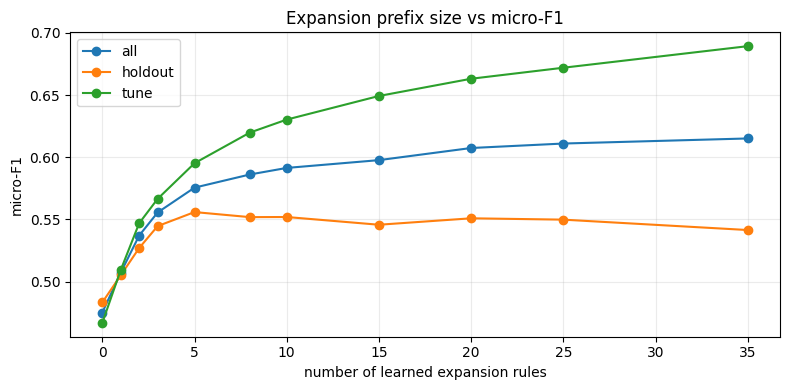

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
for split, sub in prefix.groupby("split"):
    ax.plot(sub["n_rules"], sub["micro_f1"], marker="o", label=split)
ax.set_title("Expansion prefix size vs micro-F1")
ax.set_xlabel("number of learned expansion rules")
ax.set_ylabel("micro-F1")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

## Per-factor diagnostics

In [13]:
practical = pd.read_csv(OUT / "v3_clean_broad_weak_best_practical_per_factor_report.csv")
expanded = pd.read_csv(OUT / "v3_clean_broad_weak_expanded_per_factor_report.csv")

compare = practical.merge(
    expanded[["factor_key", "precision", "recall", "f1", "predicted"]],
    on="factor_key",
    suffixes=("_base_ensemble", "_expanded"),
)
compare["f1_delta_expanded_minus_base"] = compare["f1_expanded"] - compare["f1_base_ensemble"]
display(compare.sort_values("support", ascending=False).head(24).round(4))
display(compare[compare["support"].gt(0)].sort_values("f1_base_ensemble").head(15).round(4))

,factor_key,support,predicted_base_ensemble,precision_base_ensemble,recall_base_ensemble,f1_base_ensemble,tp,fp,fn,precision_expanded,recall_expanded,f1_expanded,predicted_expanded,f1_delta_expanded_minus_base
0,industrial_production_index,130,87,0.8621,0.5769,0.6912,75,12,55,0.7143,0.8846,0.7904,161,0.0991
1,enterprises_count,100,38,0.8684,0.3300,0.4783,33,5,67,0.7184,0.7400,0.7291,103,0.2508
2,crime_count,73,58,0.7759,0.6164,0.6870,45,13,28,0.7027,0.7123,0.7075,74,0.0205
3,consumer_price_index,64,48,0.6875,0.5156,0.5893,33,15,31,0.5676,0.6562,0.6087,74,0.0194
4,life_expectancy,51,14,0.7857,0.2157,0.3385,11,3,40,0.5652,0.7647,0.6500,69,0.3115
5,real_income_index,47,2,0.5000,0.0213,0.0408,1,1,46,0.5672,0.8085,0.6667,67,0.6259
6,per_capita_income,40,9,0.7778,0.1750,0.2857,7,2,33,0.4098,0.6250,0.4950,61,0.2093
7,mortality_rate,26,20,0.6500,0.5000,0.5652,13,7,13,0.5263,0.7692,0.6250,38,0.0598
8,hospitals,20,34,0.4118,0.7000,0.5185,14,20,6,0.4359,0.8500,0.5763,39,0.0578
9,air_pollution,17,24,0.2083,0.2941,0.2439,5,19,12,0.2857,0.7059,0.4068,42,0.1629


,factor_key,support,predicted_base_ensemble,precision_base_ensemble,recall_base_ensemble,f1_base_ensemble,tp,fp,fn,precision_expanded,recall_expanded,f1_expanded,predicted_expanded,f1_delta_expanded_minus_base
14,unemployment_rate,6,5,0.0000,0.0000,0.0000,0,5,6,0.1250,0.1667,0.1429,8,0.1429
26,marriage_rate,1,0,0.0000,0.0000,0.0000,0,0,1,0.0000,0.0000,0.0000,0,0.0000
25,divorce_rate,1,0,0.0000,0.0000,0.0000,0,0,1,0.0000,0.0000,0.0000,0,0.0000
23,male_population,2,0,0.0000,0.0000,0.0000,0,0,2,0.0000,0.0000,0.0000,0,0.0000
22,international_outflow,2,24,0.0000,0.0000,0.0000,0,24,2,0.0000,0.0000,0.0000,24,0.0000
20,birth_rate_per_1000,3,0,0.0000,0.0000,0.0000,0,0,3,0.0000,0.0000,0.0000,0,0.0000
17,living_wage,4,1,0.0000,0.0000,0.0000,0,1,4,0.0000,0.0000,0.0000,1,0.0000
27,infant_mortality,1,1,0.0000,0.0000,0.0000,0,1,1,0.0000,0.0000,0.0000,1,0.0000
28,outpatient_clinics,1,2,0.0000,0.0000,0.0000,0,2,1,0.0000,0.0000,0.0000,2,0.0000
5,real_income_index,47,2,0.5000,0.0213,0.0408,1,1,46,0.5672,0.8085,0.6667,67,0.6259


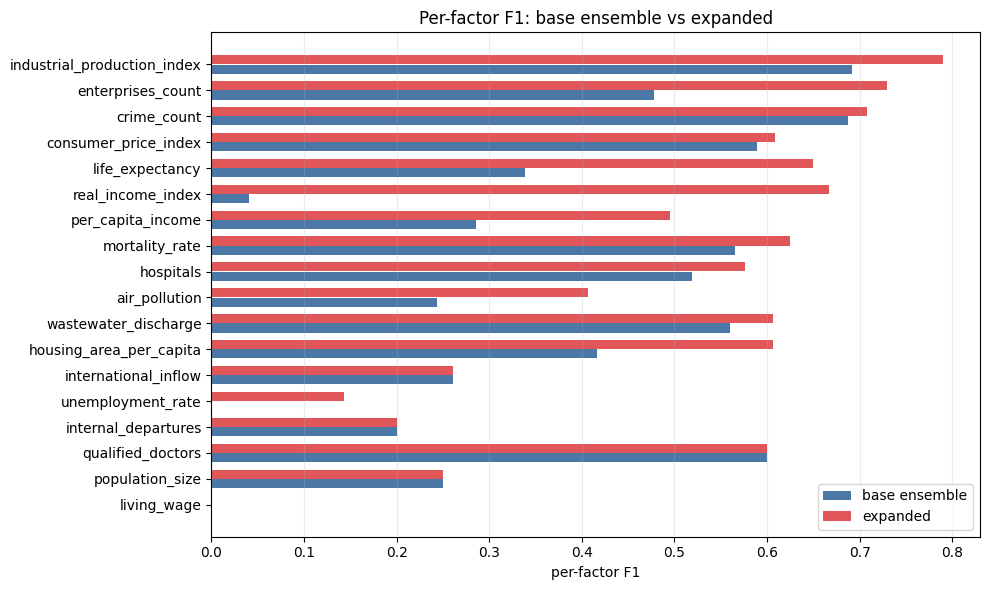

In [14]:
top_compare = compare[compare["support"].gt(0)].sort_values("support", ascending=False).head(18).iloc[::-1]
y = np.arange(len(top_compare))
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(y - 0.18, top_compare["f1_base_ensemble"], height=0.35, label="base ensemble", color="#4c78a8")
ax.barh(y + 0.18, top_compare["f1_expanded"], height=0.35, label="expanded", color="#e15759")
ax.set_yticks(y)
ax.set_yticklabels(top_compare["factor_key"])
ax.set_xlabel("per-factor F1")
ax.set_title("Per-factor F1: base ensemble vs expanded")
ax.grid(axis="x", alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

## Problem examples

In [15]:
problems = pd.read_csv(OUT / "v3_clean_broad_weak_problem_examples_best_practical.csv")
problems[["dataset_row_id", "title", "gold", "pred", "fp", "fn", "n_fp", "n_fn"]].head(20)

,dataset_row_id,title,gold,pred,fp,fn,n_fp,n_fn
0,396,ФАС выявила сговор на торгах по поставке жизненно важных лекарств,life_expectancy;real_income_index;hospitals;consumer_price_index;industrial_production_index;enterprises_count;crime...,consumer_price_index,NaN,crime_count;enterprises_count;hospitals;industrial_production_index;life_expectancy;real_income_index,0,6
1,946,"Суд запретил экс-предправления московского банка ""Легион"" Сокеркину выезжать из РФ",per_capita_income;real_income_index;industrial_production_index;enterprises_count;crime_count,international_outflow,international_outflow,crime_count;enterprises_count;industrial_production_index;per_capita_income;real_income_index,1,5
2,654,Правительство сохранило статус государственных научных центров за 43 организациями,per_capita_income;real_income_index;hospitals;qualified_doctors;consumer_price_index;industrial_production_index;ent...,qualified_doctors;enterprises_count,NaN,consumer_price_index;hospitals;industrial_production_index;per_capita_income;real_income_index,0,5
3,247,В I чтении принят проект об увеличении сроков геологоразведки для двух районов ХМАО,population_size;per_capita_income;real_income_index;consumer_price_index;industrial_production_index;enterprises_count,industrial_production_index,NaN,consumer_price_index;enterprises_count;per_capita_income;population_size;real_income_index,0,5
4,599,Рубль утром понижается в паре с юанем перед пятничным заседанием ЦБ РФ по ставке,per_capita_income;real_income_index;consumer_price_index;industrial_production_index;enterprises_count;crime_count,consumer_price_index,NaN,crime_count;enterprises_count;industrial_production_index;per_capita_income;real_income_index,0,5
5,273,КТК сообщил о повреждении выносного причала N2 в результате террористической атаки,life_expectancy;industrial_production_index;enterprises_count;crime_count;mortality_rate,crime_count;air_pollution;wastewater_discharge,air_pollution;wastewater_discharge,enterprises_count;industrial_production_index;life_expectancy;mortality_rate,2,4
6,9,В посольстве РФ рассказали о планах Британии отказаться от российского урана к 2028 году,per_capita_income;industrial_production_index;enterprises_count;air_pollution,international_inflow;international_outflow,international_inflow;international_outflow,air_pollution;enterprises_count;industrial_production_index;per_capita_income,2,4
7,341,Введение санкций США в отношении сербской энергокомпании NIS отложено на 30 дней,per_capita_income;industrial_production_index;enterprises_count;air_pollution,international_inflow;international_outflow,international_inflow;international_outflow,air_pollution;enterprises_count;industrial_production_index;per_capita_income,2,4
8,892,"Премьер Эстонии заявил, что НАТО увеличит свое присутствие в Балтийском море",life_expectancy;consumer_price_index;industrial_production_index;crime_count,international_inflow;international_outflow,international_inflow;international_outflow,consumer_price_index;crime_count;industrial_production_index;life_expectancy,2,4
9,399,"СКР проводит выемку документов в авиакомпании ""Ангара"" после крушения Ан-24",life_expectancy;unemployment_rate;industrial_production_index;enterprises_count;crime_count;wastewater_discharge;mor...,life_expectancy;hospitals;crime_count;mortality_rate,hospitals,enterprises_count;industrial_production_index;unemployment_rate;wastewater_discharge,1,4


## Conclusions

1. The v3 dataset is valid structurally: 36 factor columns are present, IDs are unique, UTF-8/BOM reads cleanly.
2. The new gold is much broader than v2: 2765 positive factor pairs, 2.77 labels/news on average, and only 33 empty news.
3. The LLM relevance gate is strong. On the 237-row search overlap, best broad prompts reach `any_relevant_f1` around 0.97.
4. The main weakness is factor-set completeness, not "is this news relevant at all". The model often emits one obvious factor
   and misses contextual v3 co-labels.
5. Best cached single source on v3-all labels is `latent_candidate_v3` at micro-F1 about 0.426.
6. Best prompt union reaches micro-F1 about 0.475.
7. A v3-aware expansion layer improves holdout micro-F1 from about 0.483 to about 0.556 with the first 5 learned rules.
   The full greedy 35-rule expansion reaches about 0.615 on all 237 rows, but its holdout curve shows overfitting risk.

Practical next step: do not solve this only by lowering thresholds. Use a two-stage pipeline:
high-recall candidate generation, v3-aware co-label expansion, then a verifier/reranker that removes weak false positives.